In [52]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load Breast Cancer dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Show first 5 rows
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

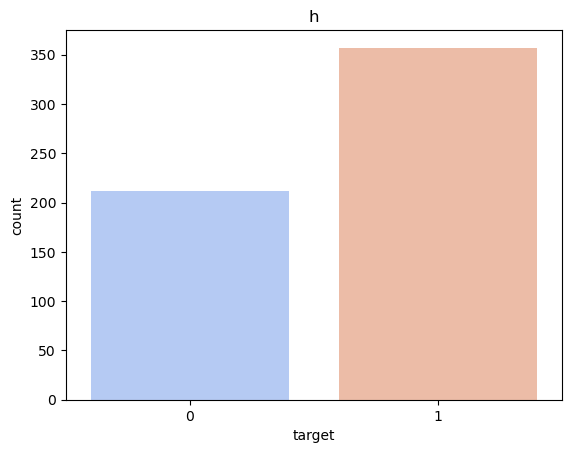

In [53]:
sns.countplot(x="target", data=df, palette="coolwarm")
plt.title('h')
plt.show()

In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


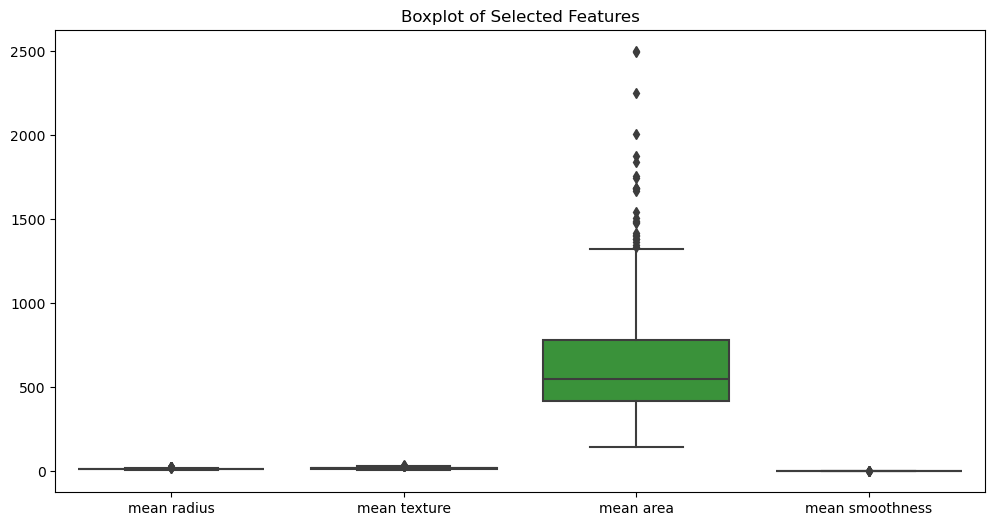

In [55]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['mean radius', 'mean texture', 'mean area', 'mean smoothness']])
plt.title("Boxplot of Selected Features")
plt.show()

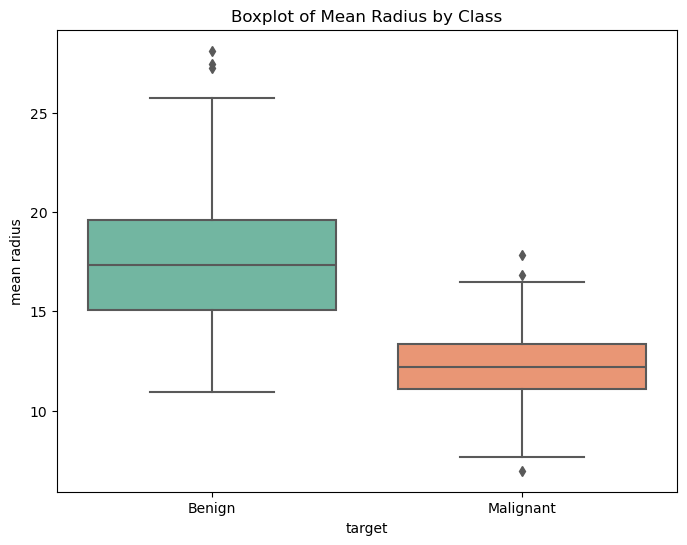

In [56]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target', y='mean radius', data=df, palette='Set2')
plt.title("Boxplot of Mean Radius by Class")
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.show()

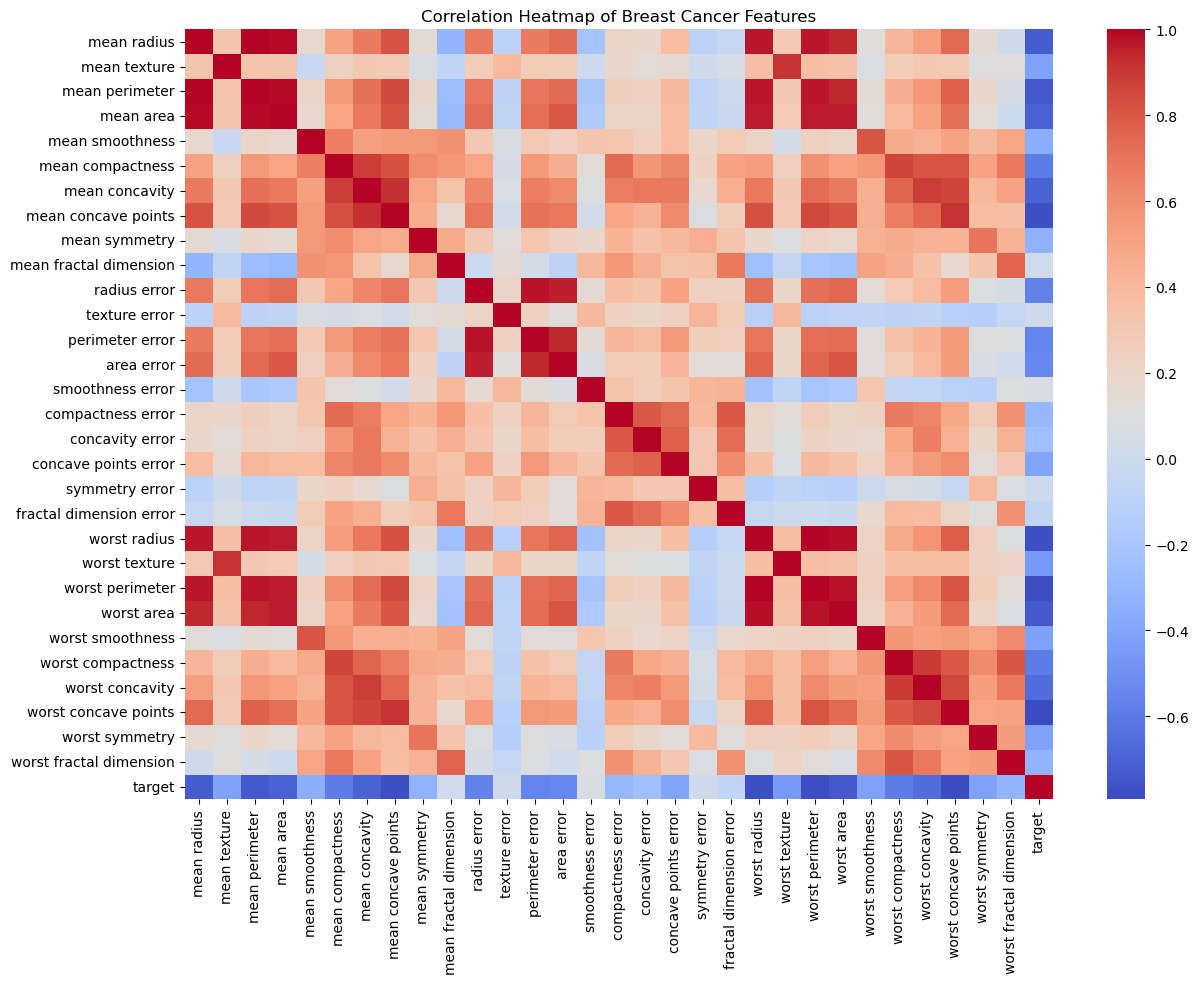

In [57]:
# Calculate correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Breast Cancer Features")
plt.show()

In [58]:
# Correlation with target
corr_target = df.corr()['target'].sort_values(ascending=False)

# Show top correlated features
print(corr_target)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

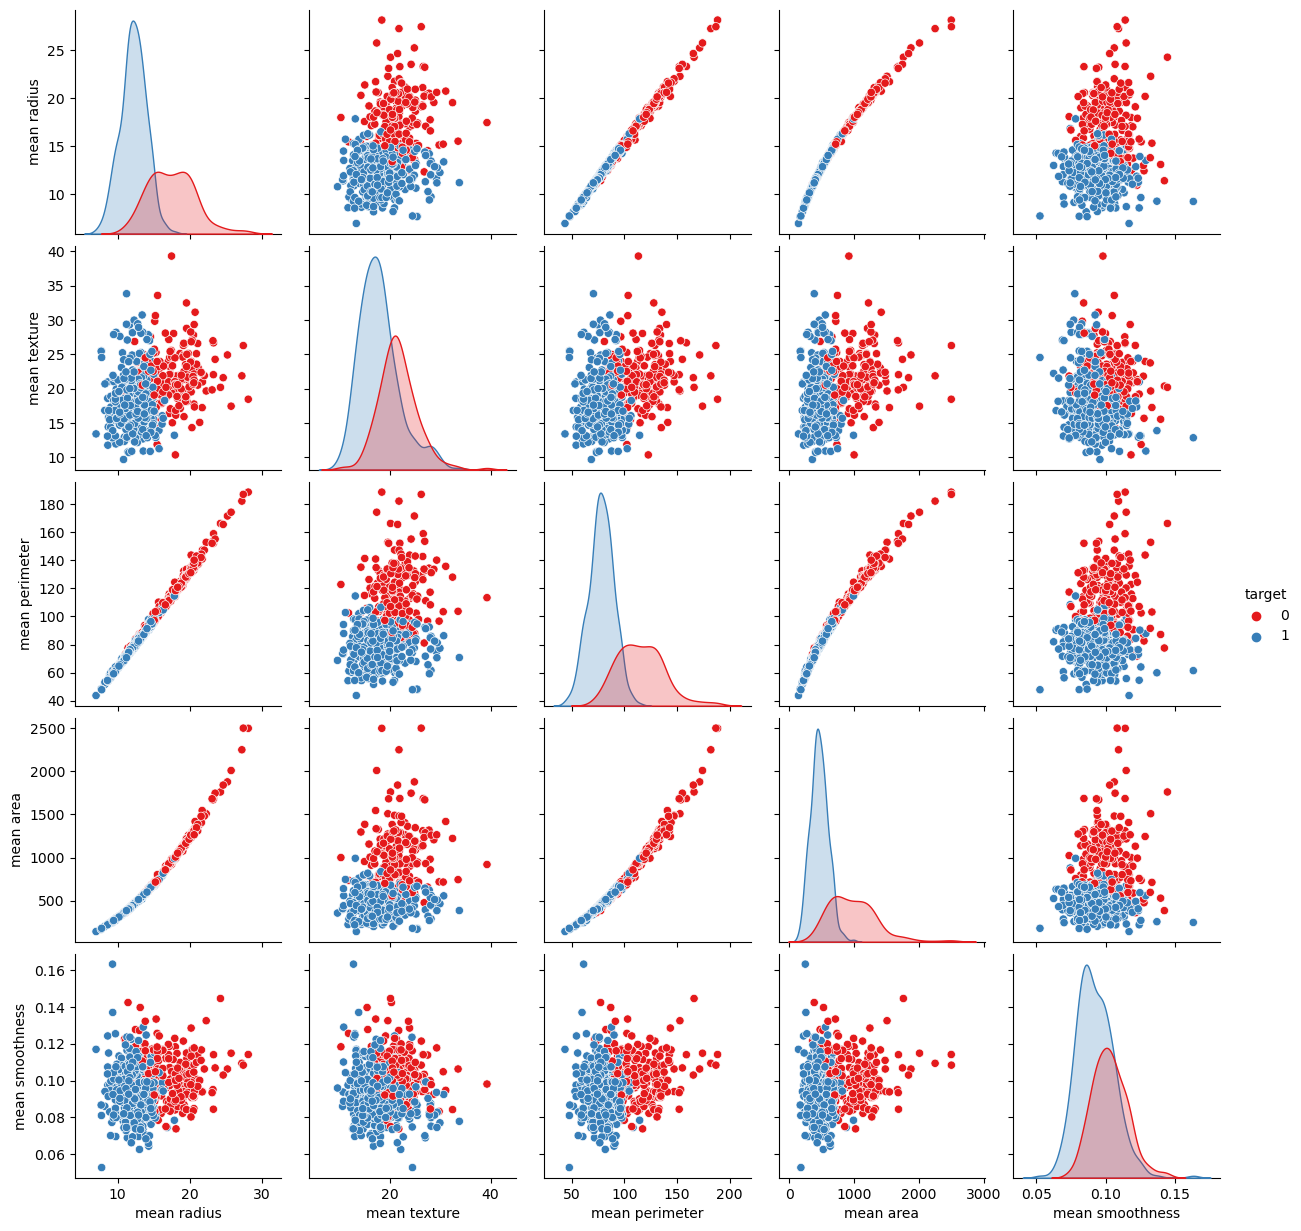

In [59]:
# Select important features
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'target']

# Subset DataFrame
df_subset = df[selected_features]

# Pairplot
sns.pairplot(df_subset, hue="target", palette="Set1", diag_kind="kde")
plt.show()

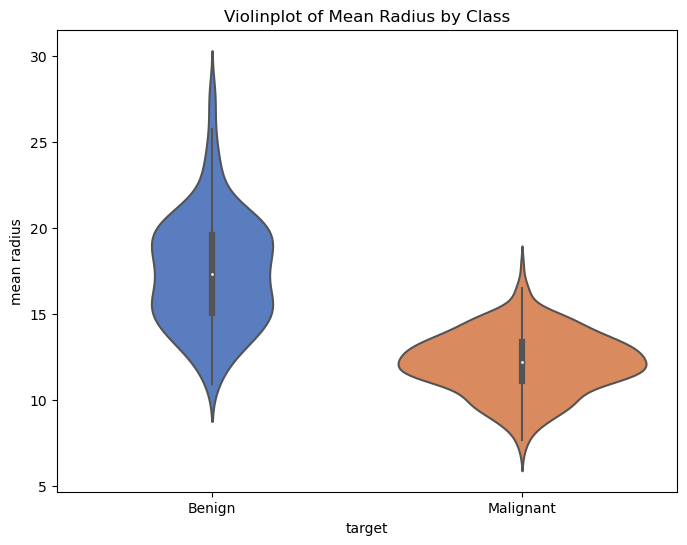

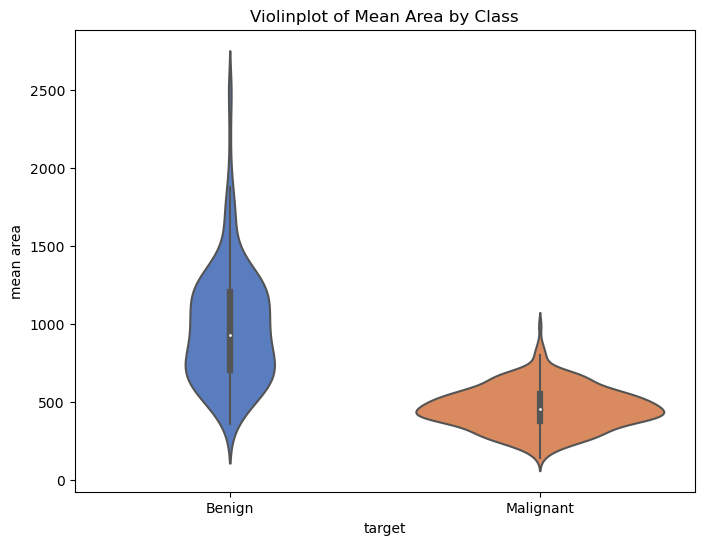

In [60]:
# Violinplot for mean radius
plt.figure(figsize=(8,6))
sns.violinplot(x="target", y="mean radius", data=df, palette="muted")
plt.title("Violinplot of Mean Radius by Class")
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.show()

# Violinplot for mean area
plt.figure(figsize=(8,6))
sns.violinplot(x="target", y="mean area", data=df, palette="muted")
plt.title("Violinplot of Mean Area by Class")
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.show()

In [61]:
# Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

In [62]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [63]:
from sklearn.model_selection import StratifiedKFold

# Define StratifiedKFold (preserves class distribution in folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Define Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Cross Validation (Accuracy)
scores = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='accuracy')

# Print accuracy for each fold
print("Accuracy for each fold:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

Accuracy for each fold: [0.96491228 0.93859649 0.95614035 0.94736842 0.97345133]
Mean Accuracy: 0.9560937742586555
Standard Deviation: 0.012339688646904016


/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


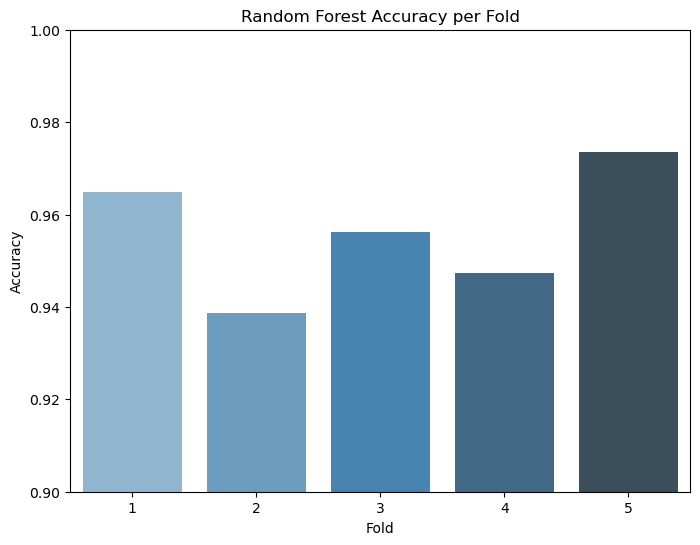

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Barplot of accuracy scores
plt.figure(figsize=(8,6))
sns.barplot(x=list(range(1, len(scores)+1)), y=scores, palette="Blues_d")
plt.title("Random Forest Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

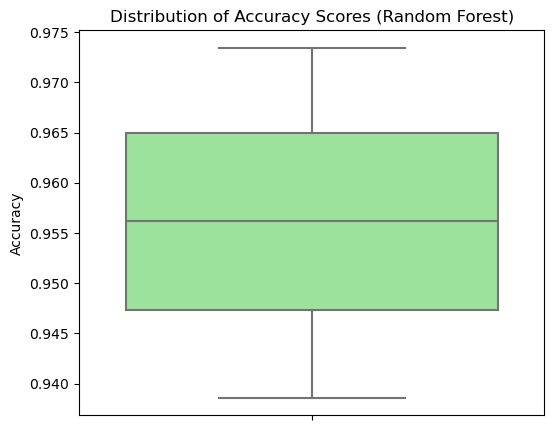

In [66]:
# Boxplot of accuracy scores
plt.figure(figsize=(6,5))
sns.boxplot(y=scores, color="lightgreen")
plt.title("Distribution of Accuracy Scores (Random Forest)")
plt.ylabel("Accuracy")
plt.show()

In [67]:
# Train Random Forest on full dataset
rf_model.fit(X_scaled, y)

# Get feature importances
importances = rf_model.feature_importances_

# Create a DataFrame
feat_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

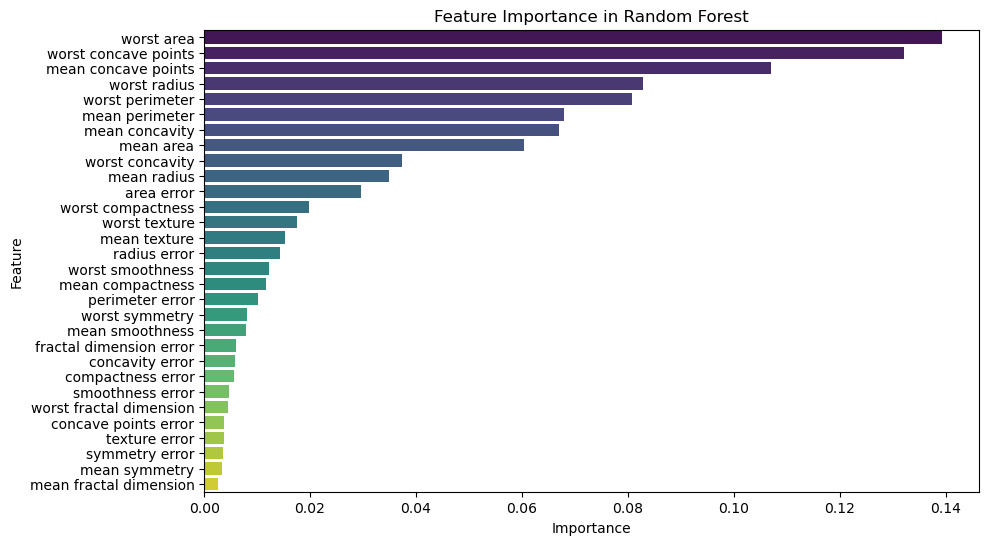

In [68]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", random_state=42,probability=True)
}

# Dictionary to store results
cv_results = {}

# Evaluate each model
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name} -> Mean Accuracy: {scores.mean():.4f} | Std: {scores.std():.4f}")

Random Forest -> Mean Accuracy: 0.9561 | Std: 0.0123
Logistic Regression -> Mean Accuracy: 0.9737 | Std: 0.0166
KNN -> Mean Accuracy: 0.9666 | Std: 0.0140
SVM -> Mean Accuracy: 0.9754 | Std: 0.0195


/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


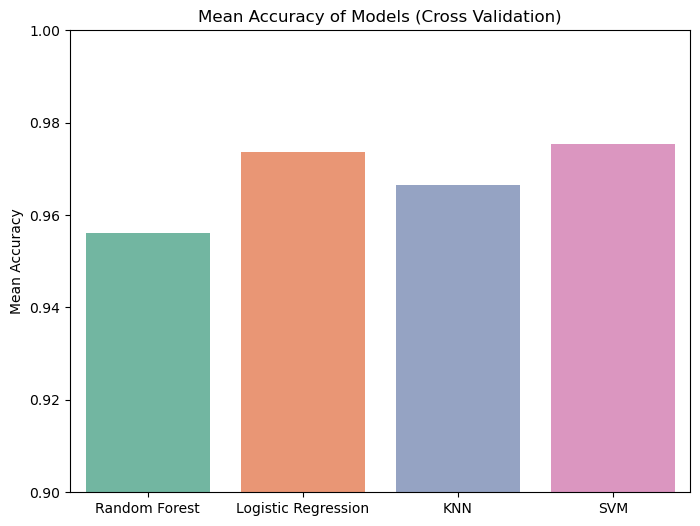

In [70]:
# Prepare mean accuracy for each model
mean_scores = {name: scores.mean() for name, scores in cv_results.items()}

plt.figure(figsize=(8,6))
sns.barplot(x=list(mean_scores.keys()), y=list(mean_scores.values()), palette="Set2")
plt.title("Mean Accuracy of Models (Cross Validation)")
plt.ylabel("Mean Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

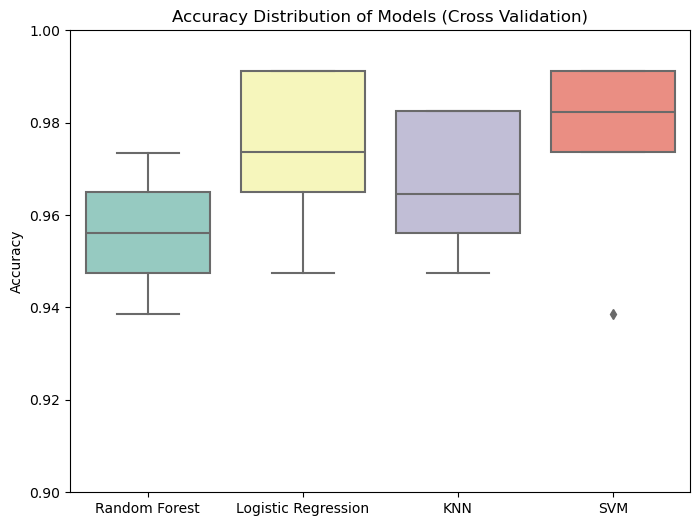

In [71]:
# Convert results to DataFrame for visualization
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(8,6))
sns.boxplot(data=cv_df, palette="Set3")
plt.title("Accuracy Distribution of Models (Cross Validation)")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

In [72]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# Dictionary to store metrics
metrics_results = {}

for name, model in models.items():
    # Cross-validated predictions
    y_pred = cross_val_predict(model, X_scaled, y, cv=cv)
    
    # Calculate metrics
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    metrics_results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_results).T
print(metrics_df)

                     Precision    Recall  F1-Score
Random Forest         0.963687  0.966387  0.965035
Logistic Regression   0.967213  0.991597  0.979253
KNN                   0.956757  0.991597  0.973865
SVM                   0.975069  0.985994  0.980501


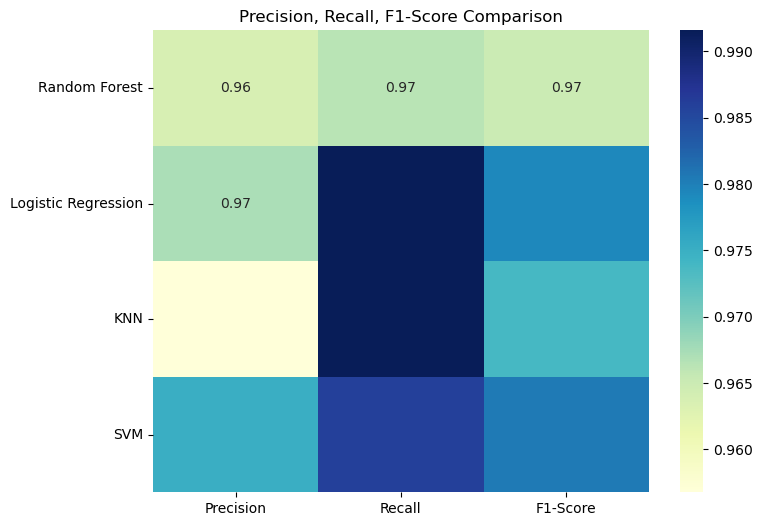

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(metrics_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Precision, Recall, F1-Score Comparison")
plt.show()


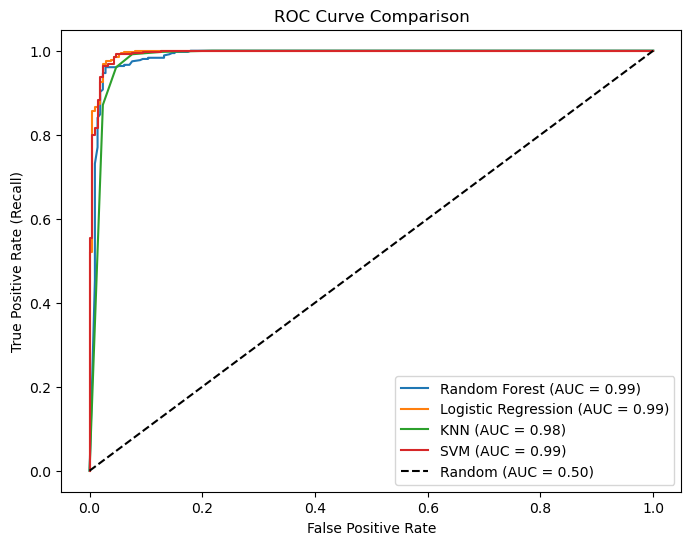

In [77]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Cross-validated predictions (probabilities)
    y_pred_proba = cross_val_predict(model, X_scaled, y, cv=cv, method="predict_proba")[:,1]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot baseline (random model)
plt.plot([0,1], [0,1], 'k--', label="Random (AUC = 0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

In [81]:
# Train Random Forest on full dataset
rf_model.fit(X_scaled, y)

# Extract feature importances
importances = rf_model.feature_importances_

# Create DataFrame for visualization
feat_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importances.head(10))  # Top 10 features

                 Feature  Importance
23            worst area    0.139357
27  worst concave points    0.132225
7    mean concave points    0.107046
20          worst radius    0.082848
22       worst perimeter    0.080850
2         mean perimeter    0.067990
6         mean concavity    0.066917
3              mean area    0.060462
26       worst concavity    0.037339
0            mean radius    0.034843


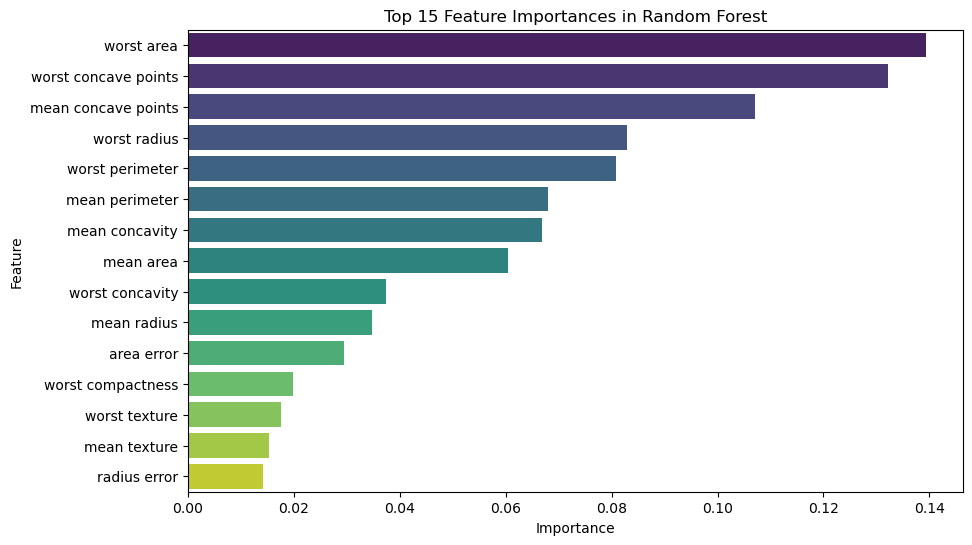

In [85]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_importances.head(15), palette="viridis")
plt.title("Top 15 Feature Importances in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [88]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_scaled, y)

# Get coefficients
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coeffs.head(10))  # Top 10 coefficients

                    Feature  Coefficient
15        compactness error     0.736282
19  fractal dimension error     0.680915
5          mean compactness     0.562595
9    mean fractal dimension     0.322186
18           symmetry error     0.295902
11            texture error     0.268925
16          concavity error     0.110526
8             mean symmetry     0.076168
25        worst compactness     0.044659
4           mean smoothness    -0.161765


In [89]:
from sklearn.inspection import permutation_importance

# Permutation importance
perm_importance = permutation_importance(rf_model, X_scaled, y, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_df.head(10))

                 Feature  Importance
1           mean texture    0.002460
7    mean concave points    0.002285
27  worst concave points    0.001757
21         worst texture    0.001757
10          radius error    0.001582
23            worst area    0.001582
15     compactness error    0.001582
13            area error    0.001054
24      worst smoothness    0.000351
6         mean concavity    0.000176


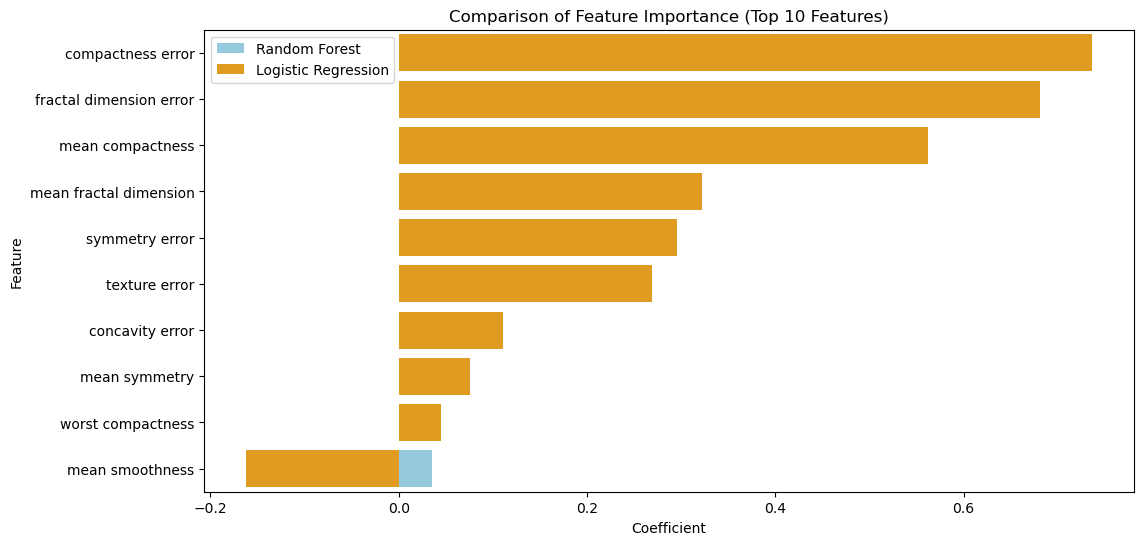

In [92]:
plt.figure(figsize=(12,6))

# Random Forest
sns.barplot(x="Importance", y="Feature", data=feat_importances.head(10), color="skyblue", label="Random Forest")

# Logistic Regression Coefficients
sns.barplot(x="Coefficient", y="Feature", data=coeffs.head(10), color="orange", label="Logistic Regression")

plt.title("Comparison of Feature Importance (Top 10 Features)")
plt.legend()
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

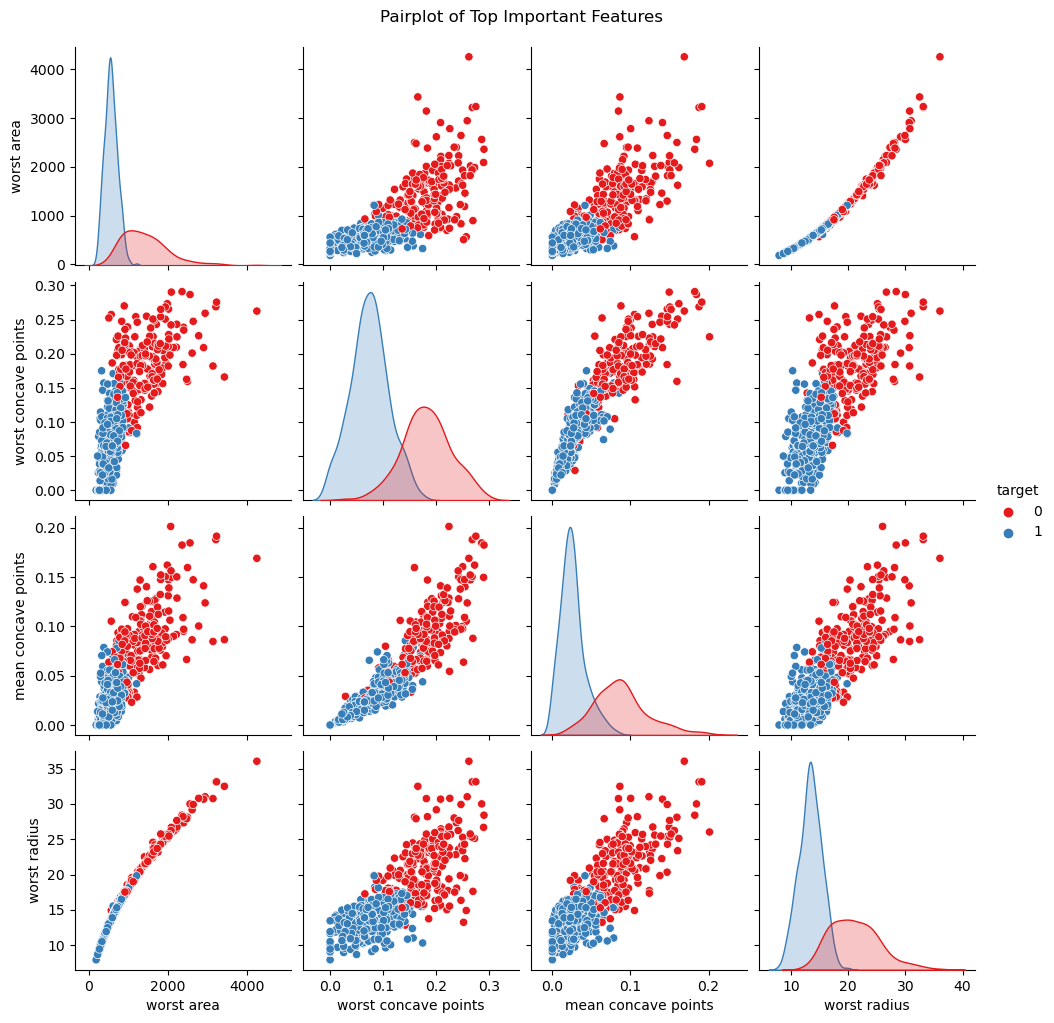

In [99]:
# Select top features based on Random Forest importance
top_features = feat_importances.head(4)["Feature"].tolist()

# Pairplot visualization
sns.pairplot(df, vars=top_features, hue="target", diag_kind="kde", palette="Set1")
plt.suptitle("Pairplot of Top Important Features", y=1.02)
plt.show()

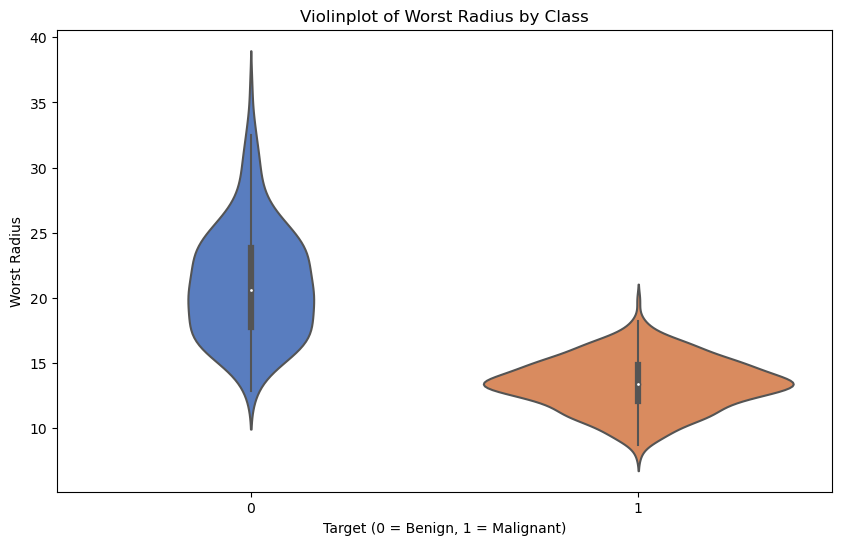

In [100]:
plt.figure(figsize=(10,6))
sns.violinplot(x="target", y="worst radius", data=df, palette="muted")
plt.title("Violinplot of Worst Radius by Class")
plt.xlabel("Target (0 = Benign, 1 = Malignant)")
plt.ylabel("Worst Radius")
plt.show()

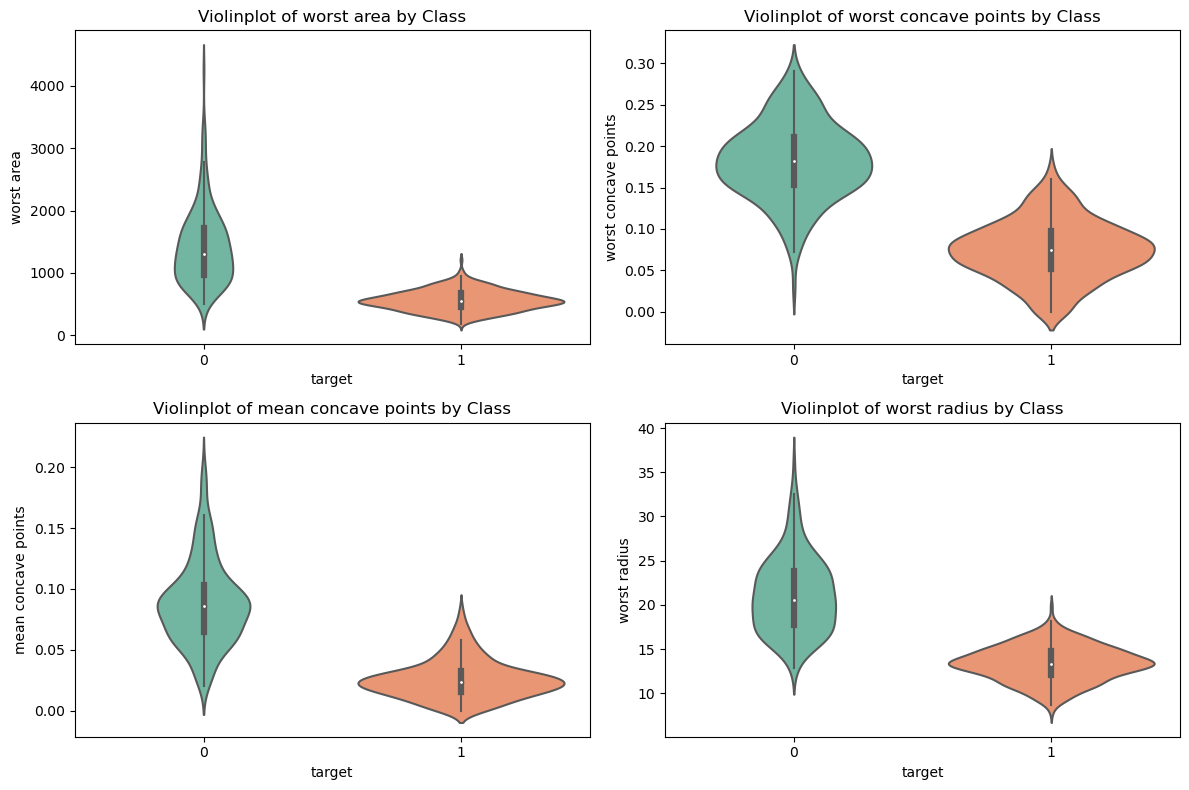

In [101]:
plt.figure(figsize=(12,8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2,2,i)
    sns.violinplot(x="target", y=feature, data=df, palette="Set2")
    plt.title(f"Violinplot of {feature} by Class")
plt.tight_layout()
plt.show()